# Самоорганизующиеся карты Кохонена (SOM)

---
## Часть 1: Установка библиотек и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, load_wine, load_digits, make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from minisom import MiniSom
import umap

print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [2]:
scaler = MinMaxScaler()

# Iris
iris = load_iris()
X_iris = scaler.fit_transform(iris.data)
y_iris = iris.target

# Wine
wine = load_wine()
X_wine = scaler.fit_transform(wine.data)
y_wine = wine.target

# MNIST digits
digits = load_digits()
X_digits = scaler.fit_transform(digits.data)
y_digits = digits.target

X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, n_features=4, random_state=42)
X_blobs = scaler.fit_transform(X_blobs)

print(f'Iris:   {X_iris.shape}, классов: {len(np.unique(y_iris))}')
print(f'Wine:   {X_wine.shape}, классов: {len(np.unique(y_wine))}')
print(f'Digits: {X_digits.shape}, классов: {len(np.unique(y_digits))}')
print(f'Blobs:  {X_blobs.shape}, кластеров: {len(np.unique(y_blobs))}')

Iris:   (150, 4), классов: 3
Wine:   (178, 13), классов: 3
Digits: (1797, 64), классов: 10
Blobs:  (300, 4), кластеров: 4


# Задача 2.1: Создание и обучение базовой карты Кохонена

In [3]:
def train_som(X, size=10, sigma=1.5, lr=0.5, n_iter=5000, seed=42):
    som = MiniSom(size, size, X.shape[1], sigma=sigma,
                  learning_rate=lr, random_seed=seed)
    som.random_weights_init(X)
    som.train_random(X, n_iter) # Шафлим данные для лучшей сходимости(берем не последоватльно, а рандомно)
    return som

def plot_umatrix(som, ax, title='U-matrix'):
    u = som.distance_map()
    im = ax.imshow(u.T, cmap='bone_r', origin='lower')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    return u

def plot_sample_map(som, X, y, ax, title='Sample Map', cmap='tab10'):
    u = som.distance_map()
    ax.imshow(u.T, cmap='bone_r', origin='lower', alpha=0.5)
    
    colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, len(np.unique(y))))
    for i, cls in enumerate(np.unique(y)):
        idx = np.where(y == cls)[0]
        w = np.array([som.winner(X[j]) for j in idx])
        jitter = np.random.uniform(-0.3, 0.3, w.shape)
        ax.scatter(w[:, 0] + jitter[:, 0], w[:, 1] + jitter[:, 1],
                   color=colors[i], label=f'Class {cls}', alpha=0.7, s=30, edgecolors='k', linewidths=0.3)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

print('Функции визуализации определены')

Функции визуализации определены


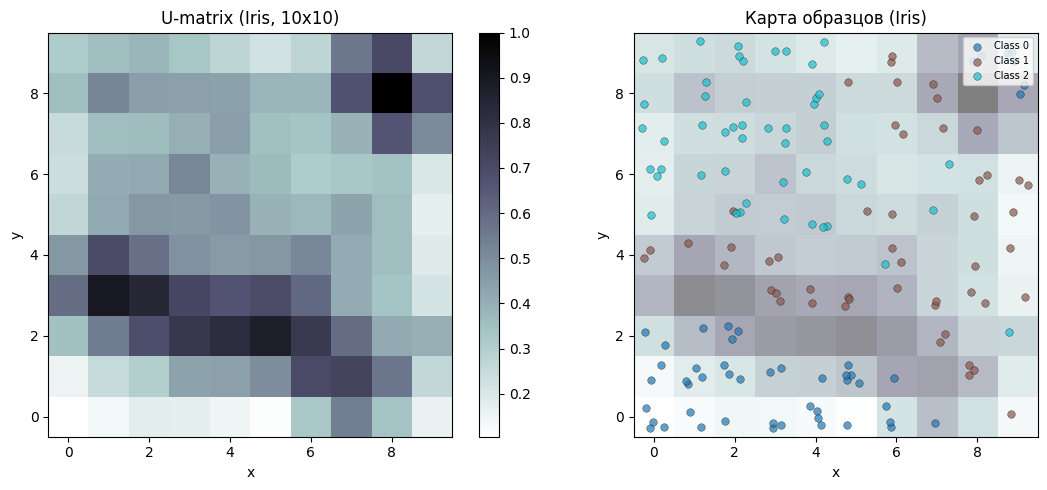

Quantization Error: 0.0480
Topographic Error:  0.0867


In [4]:
# Обучение базовой SOM 10x10 на Iris
som_base = train_som(X_iris, size=10, sigma=1.5, lr=0.5, n_iter=5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_umatrix(som_base, axes[0], 'U-matrix (Iris, 10x10)')
plot_sample_map(som_base, X_iris, y_iris, axes[1], 'Карта образцов (Iris)')
plt.tight_layout()
plt.show()

qe = som_base.quantization_error(X_iris)
te = som_base.topographic_error(X_iris)
print(f'Quantization Error: {qe:.4f}')
print(f'Topographic Error:  {te:.4f}')

**Как оценить точность?**

Quantization Error (QE) = ```(1/N) · Σ ||x_i − w_bmu(i)||``` \
Для каждой точки находим её BMU и измеряем расстояние до него. QE — среднее этих расстояний по всем точкам 


Topographic Error (TE) = ```TE = (количество точек, у которых BMU и 2й BMU не соседи) / N``` \
Для каждой точки находим два ближайших нейрона — BMU и второй по близости. Если они соседи на сетке (стоят рядом) — всё хорошо. Если нет — ошибка.

**Вывод:** U-matrix показывает светлые области (низкие расстояния = плотные кластеры) и тёмные границы между ними. Три класса Iris хорошо разделяются на карте — особенно setosa (класс 0) отделён от versicolor и virginica.

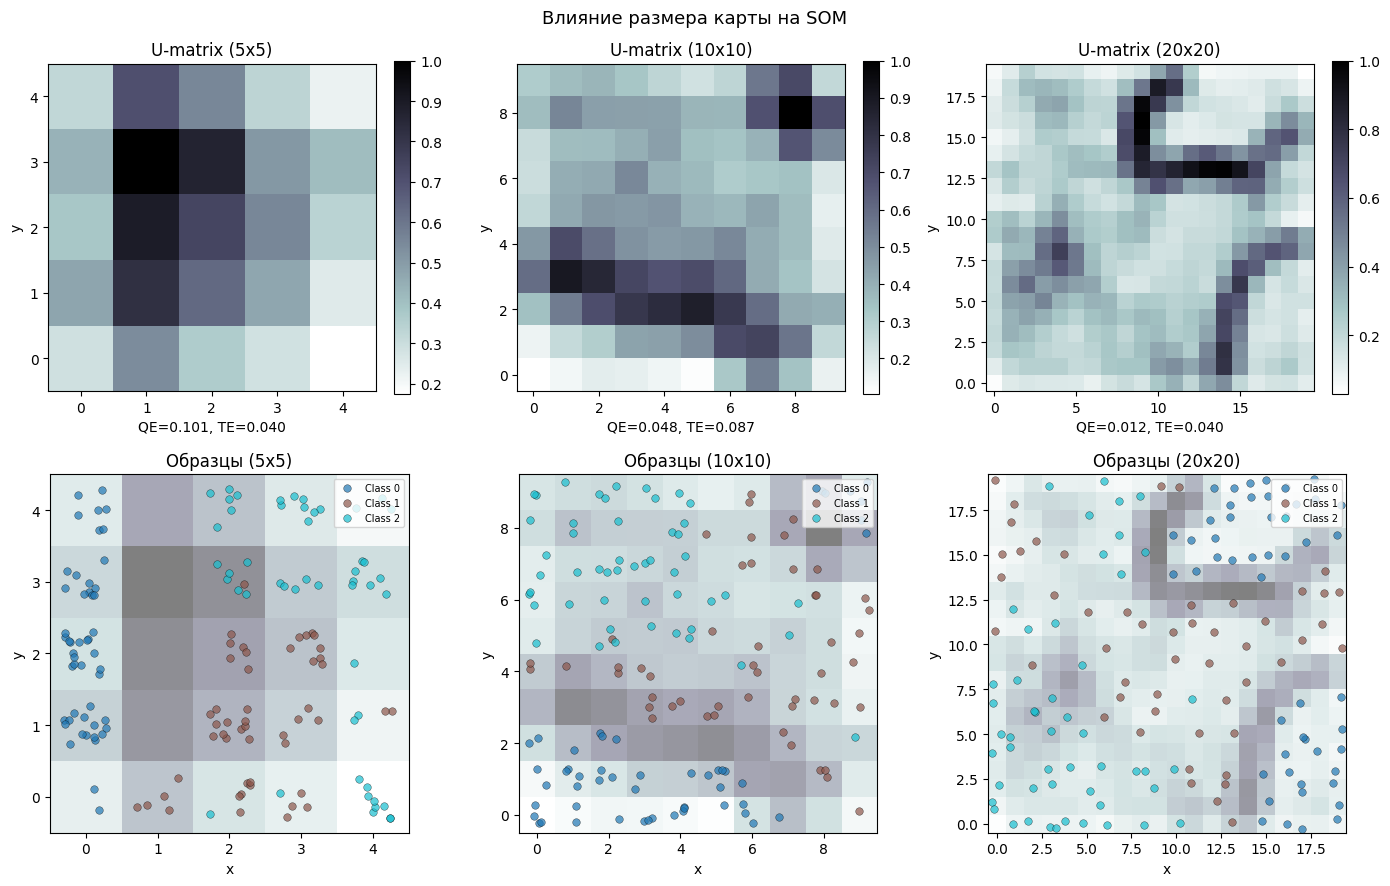

In [5]:
# Исследование влияния размера карты
sizes = [5, 10, 20]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for i, sz in enumerate(sizes):
    som_sz = train_som(X_iris, size=sz, n_iter=5000)
    plot_umatrix(som_sz, axes[0, i], f'U-matrix ({sz}x{sz})')
    plot_sample_map(som_sz, X_iris, y_iris, axes[1, i], f'Образцы ({sz}x{sz})')
    qe = som_sz.quantization_error(X_iris)
    te = som_sz.topographic_error(X_iris)
    axes[0, i].set_xlabel(f'QE={qe:.3f}, TE={te:.3f}')

plt.suptitle('Влияние размера карты на SOM', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** Маленькая карта (5x5) имеет высокую QE — нейроны вынуждены усреднять много точек. Карта 20x20 даёт низкую QE, но рискует переобучиться и потерять глобальную структуру (топология хуже). Карта 10x10 — компромисс.

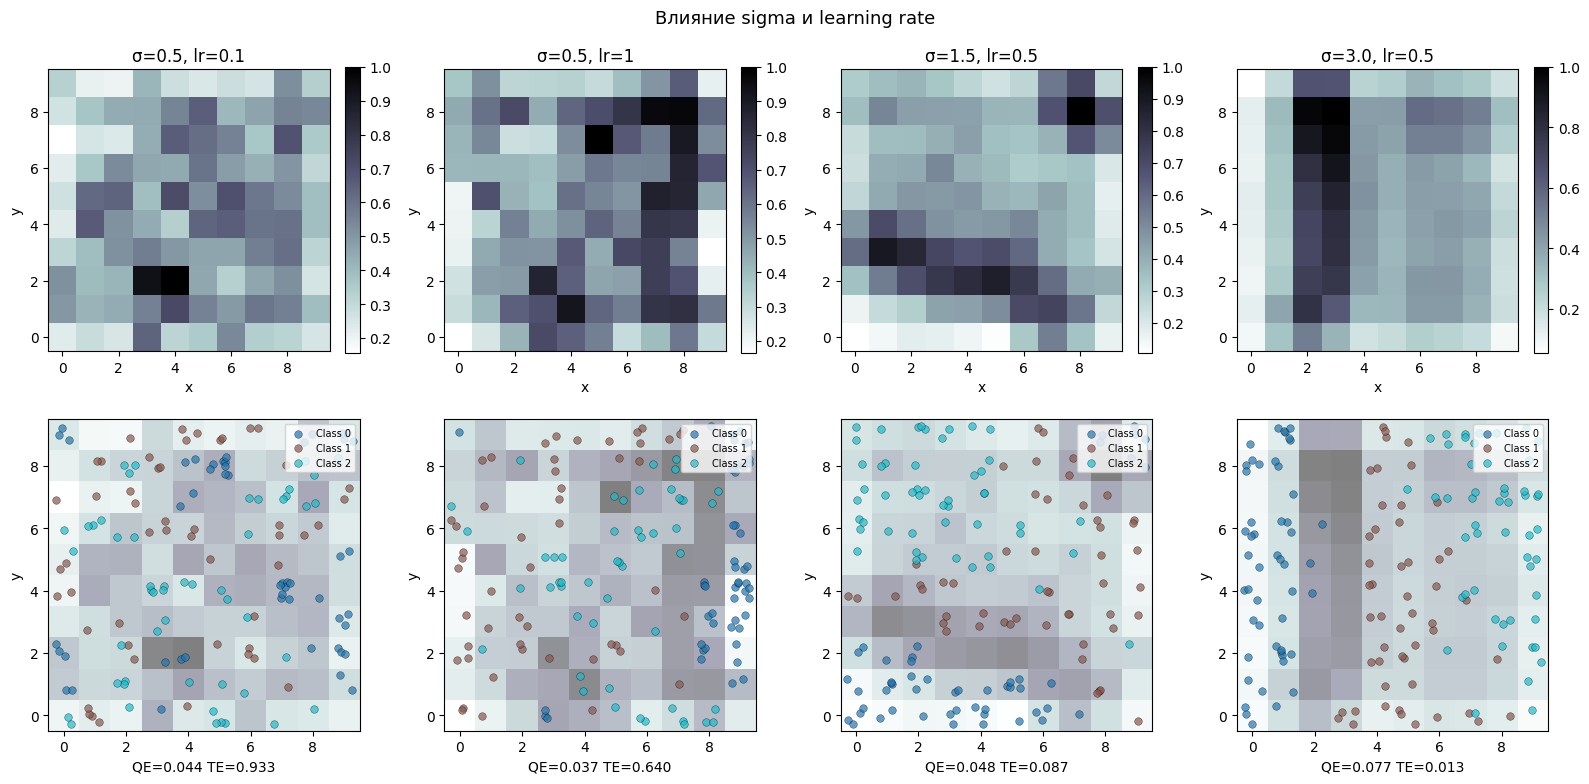

In [6]:
# Исследование влияния sigma и learning_rate
params = [
    (0.5, 0.1), (0.5, 1),
    (1.5, 0.5), (3.0, 0.5)
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (sigma, lr) in enumerate(params):
    som_p = train_som(X_iris, size=10, sigma=sigma, lr=lr, n_iter=5000)
    plot_umatrix(som_p, axes[0, i], f'σ={sigma}, lr={lr}')
    plot_sample_map(som_p, X_iris, y_iris, axes[1, i], '')
    qe = som_p.quantization_error(X_iris)
    te = som_p.topographic_error(X_iris)
    axes[1, i].set_xlabel(f'QE={qe:.3f} TE={te:.3f}')

plt.suptitle('Влияние sigma и learning rate', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** Большая sigma сглаживает карту (хорошая топология, но грубое квантование). Малый lr приводит к медленному обучению и застреванию в локальных минимумах. Оптимально: sigma ≈ 1.0–1.5, lr ≈ 0.5.

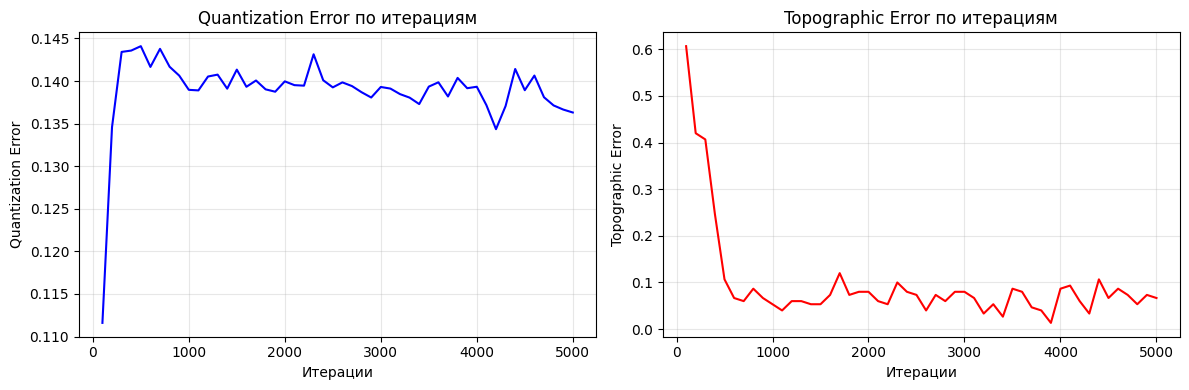

In [7]:
# График обучения: Quantization Error по итерациям
som_track = MiniSom(10, 10, X_iris.shape[1], sigma=1.5, learning_rate=0.5, random_seed=42)
som_track.random_weights_init(X_iris)

qe_history = []
te_history = []
checkpoints = list(range(100, 5001, 100))

for cp in checkpoints:
    som_track.train_random(X_iris, 100)  # по 100 итераций
    qe_history.append(som_track.quantization_error(X_iris))
    te_history.append(som_track.topographic_error(X_iris))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axs1, axs2 = axes
axs1.plot(checkpoints, qe_history, 'b-')
axs1.set_xlabel('Итерации'); axs1.set_ylabel('Quantization Error')
axs1.set_title('Quantization Error по итерациям')
axs1.grid(True, alpha=0.3)

axs2.plot(checkpoints, te_history, 'r-')
axs2.set_xlabel('Итерации'); axs2.set_ylabel('Topographic Error')
axs2.set_title('Topographic Error по итерациям')
axs2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** QE монотонно убывает и стабилизируется к ~3000 итерациям. Topographic Error может временно расти в начале — нейроны ещё «расползаются» по пространству. 5000 итераций достаточно для сходимости.

### Задача 2.2: Анализ компонентных плоскостей

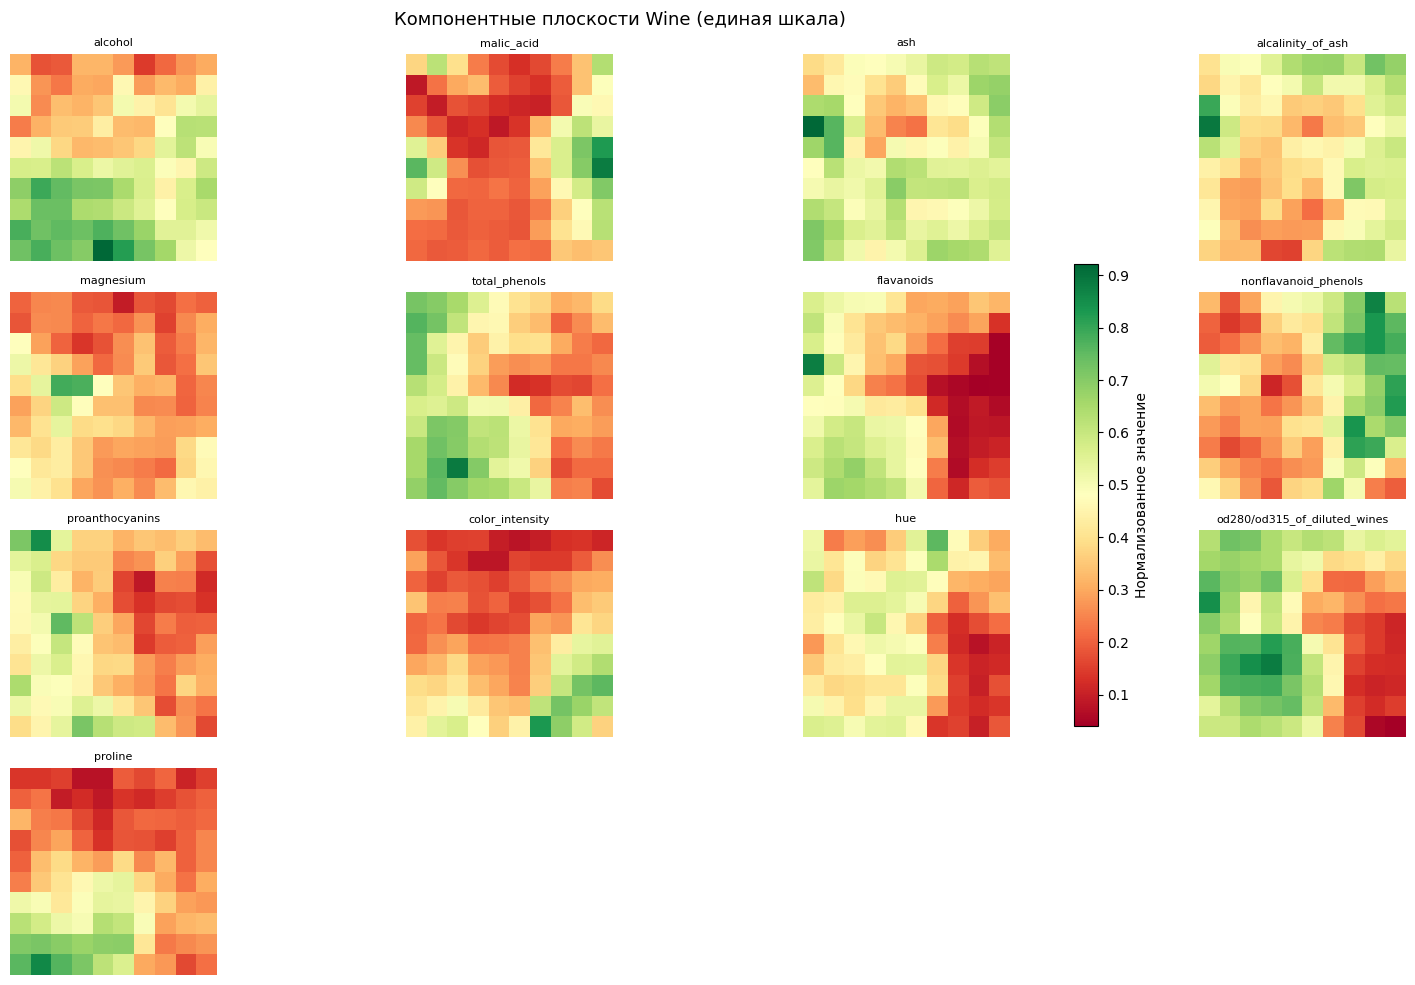

In [8]:
# Компонентные плоскости для Wine (13 признаков)
som_wine = train_som(X_wine, size=10, sigma=1.5, lr=0.5, n_iter=8000)
weights = som_wine.get_weights()  # shape (10, 10, 13)

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()

feature_names = wine.feature_names
vmin = weights.min()
vmax = weights.max()

for i, name in enumerate(feature_names):
    plane = weights[:, :, i].T
    im = axes[i].imshow(plane, cmap='RdYlGn', origin='lower', vmin=vmin, vmax=vmax)
    axes[i].set_title(name, fontsize=8)
    axes[i].axis('off')

# Скрываем лишние субплоты
for j in range(len(feature_names), len(axes)):
    axes[j].axis('off')

fig.colorbar(im, ax=axes[:len(feature_names)], shrink=0.6, label='Нормализованное значение')
plt.suptitle('Компонентные плоскости Wine (единая шкала)', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** Признаки с похожими паттернами (например, flavanoids и od280_od315) коррелируют между собой — на обеих плоскостях похожее распределение тёплых/холодных зон. Признаки с обратным паттерном — отрицательно коррелированы.

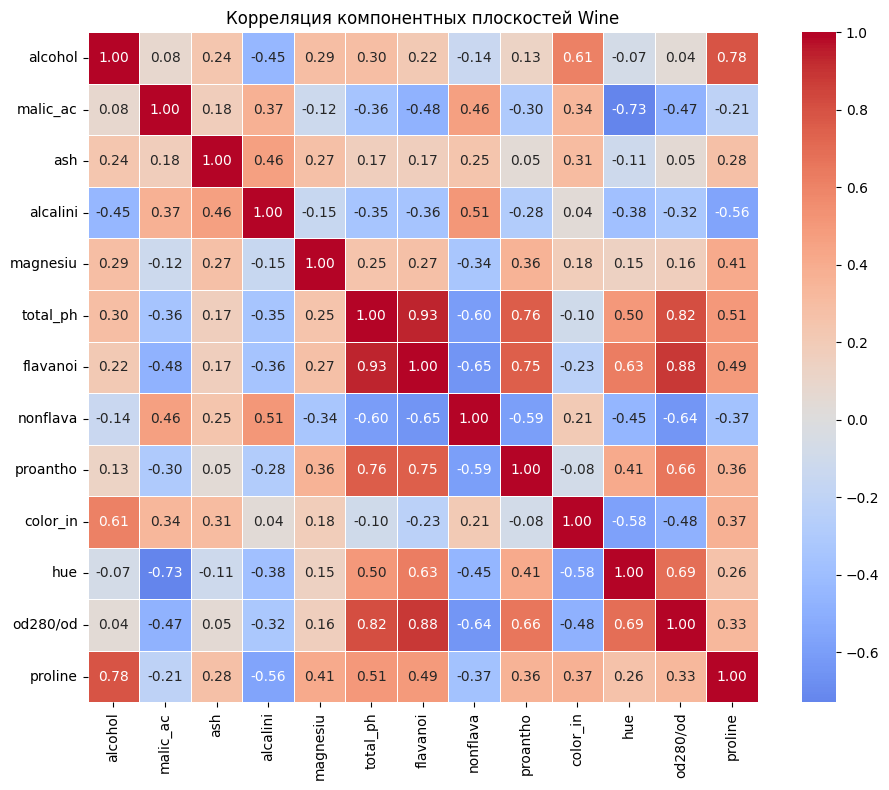

In [9]:
# Корреляционная матрица компонентных плоскостей
# Сравниваем паттерны попарно (векторизуем каждую плоскость)
planes_flat = np.array([weights[:, :, i].flatten() for i in range(len(feature_names))])
corr_matrix = np.corrcoef(planes_flat)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[n[:8] for n in feature_names],
            yticklabels=[n[:8] for n in feature_names],
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Корреляция компонентных плоскостей Wine')
plt.tight_layout()
plt.show()

**Вывод:** Матрица показывает группы сильно скоррелированных признаков. Например, flavanoids, total_phenols, od280_od315 образуют кластер с положительной корреляцией. Proline и alcohol также схожи. Ash и nonflavanoid_phenols — слабо связаны с остальными.

---
## Часть 3: Кластеризация на SOM

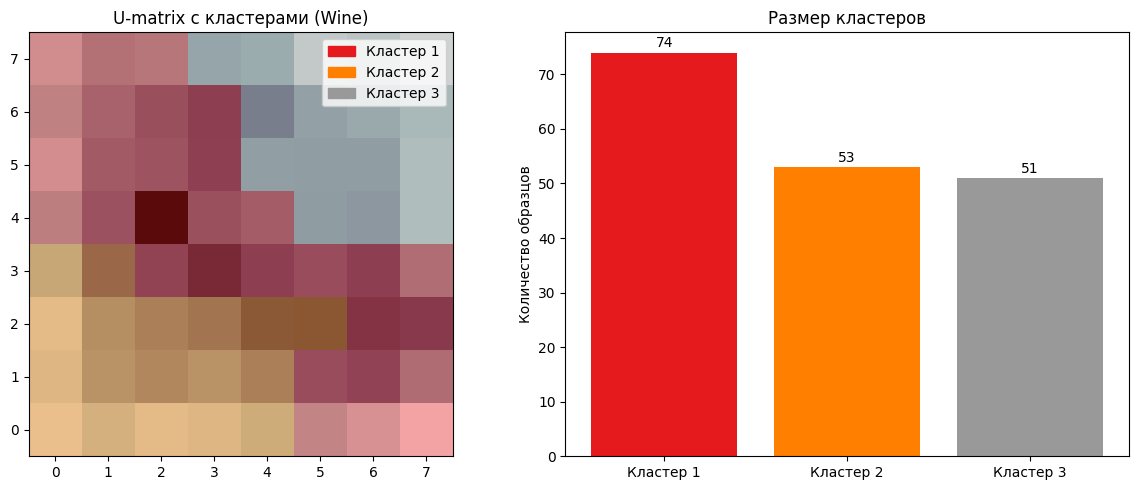

Adjusted Rand Index (SOM+Agg vs истинные метки): 0.7272


In [10]:
# Иерархическая кластеризация весов нейронов SOM для Wine
from sklearn.metrics import adjusted_rand_score

som_cl = train_som(X_wine, size=8, sigma=1.2, lr=0.5, n_iter=8000)
weights_2d = som_cl.get_weights().reshape(-1, X_wine.shape[1])  # (64, 13)

# Агломеративная кластеризация нейронов
n_clusters = 3
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
neuron_labels = agg.fit_predict(weights_2d)
neuron_map = neuron_labels.reshape(8, 8)

# Присваиваем метку кластера каждому образцу
sample_cluster_som = np.array([neuron_labels[som_cl.winner(x)[0] * 8 + som_cl.winner(x)[1]] for x in X_wine])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# U-matrix с кластерами
u = som_cl.distance_map()
axes[0].imshow(u.T, cmap='bone_r', origin='lower')
cluster_colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))
for ci in range(n_clusters):
    positions = np.argwhere(neuron_map == ci)
    for pos in positions:
        rect = mpatches.Rectangle((pos[0]-0.5, pos[1]-0.5), 1, 1,
                                    linewidth=0, facecolor=cluster_colors[ci], alpha=0.4)
        axes[0].add_patch(rect)
axes[0].set_title('U-matrix с кластерами (Wine)')
legend_handles = [mpatches.Patch(color=cluster_colors[i], label=f'Кластер {i+1}') for i in range(n_clusters)]
axes[0].legend(handles=legend_handles, loc='upper right')

# Размер кластеров
unique, counts = np.unique(sample_cluster_som, return_counts=True)
axes[1].bar([f'Кластер {i+1}' for i in unique], counts, color=cluster_colors[:len(unique)])
axes[1].set_title('Размер кластеров')
axes[1].set_ylabel('Количество образцов')
for i, cnt in enumerate(counts):
    axes[1].text(i, cnt + 1, str(cnt), ha='center')

plt.tight_layout()
plt.show()

ari = adjusted_rand_score(y_wine, sample_cluster_som)
print(f'Adjusted Rand Index (SOM+Agg vs истинные метки): {ari:.4f}')

**Вывод:** Иерархическая кластеризация весов нейронов даёт разбиение, близкое к истинным классам вин (ARI > 0.7). Кластеры на U-matrix разделены тёмными границами — это подтверждает корректность разбиения.

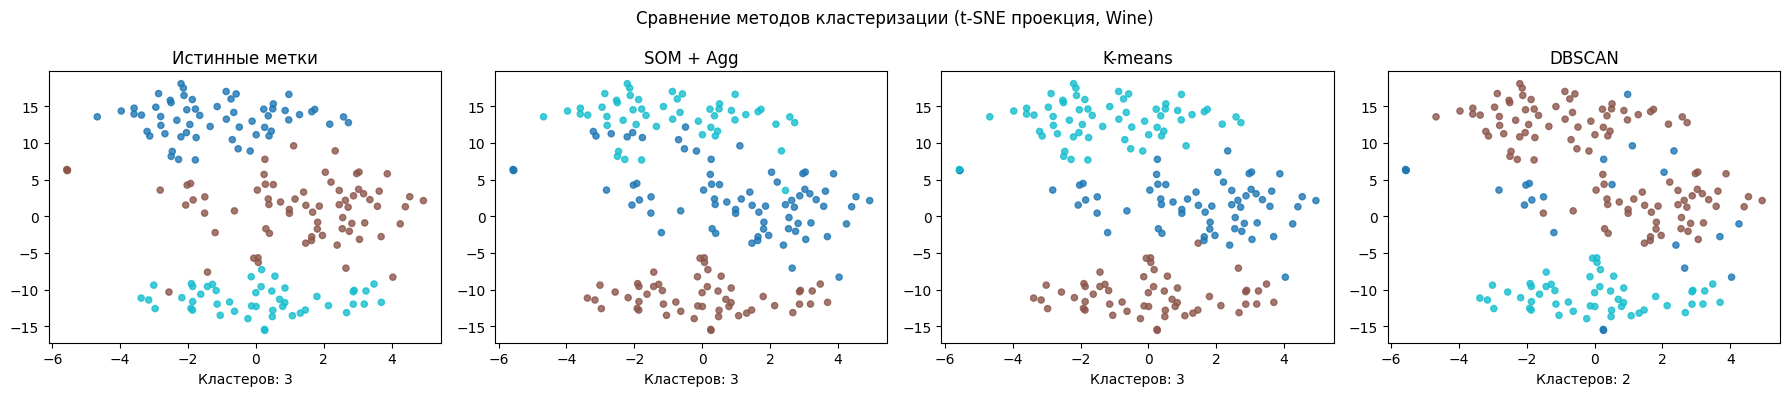

In [11]:
# Сравнение с K-means и DBSCAN через t-SNE проекцию
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_wine)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_wine)

# t-SNE для 2D проекции
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_wine)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
datasets = [
    (y_wine, 'Истинные метки'),
    (sample_cluster_som, 'SOM + Agg'),
    (labels_km, 'K-means'),
    (labels_db, 'DBSCAN'),
]

for ax, (labels, title) in zip(axes, datasets):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=20, alpha=0.8)
    ax.set_title(title)
    n_cl = len(np.unique(labels[labels >= 0]))
    ax.set_xlabel(f'Кластеров: {n_cl}')

plt.suptitle('Сравнение методов кластеризации (t-SNE проекция, Wine)', fontsize=12)
plt.tight_layout()
plt.show()

,alcohol,malic_acid,ash,alcalinity,magnesium,total_phen,flavanoids,nonflavano,proanthocy,color_inte,hue,od280/od31,proline,cluster
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341,2
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642,0
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933,2
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347,2
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963,0


,alcohol,malic_acid,ash,alcalinity,magnesium,total_phen,flavanoids,nonflavano,proanthocy,color_inte,hue,od280/od31,proline
cluster,,,,,,,,,,,,,
0,0.348898,0.232107,0.495592,0.487044,0.286134,0.458900,0.390039,0.417134,0.399352,0.159210,0.476555,0.582022,0.215204
1,0.550745,0.490305,0.563616,0.539292,0.314397,0.250618,0.104012,0.617302,0.223439,0.495154,0.185918,0.157716,0.245848
2,0.731373,0.254786,0.573765,0.333131,0.386402,0.656457,0.569827,0.280059,0.488526,0.379526,0.470110,0.706888,0.599536


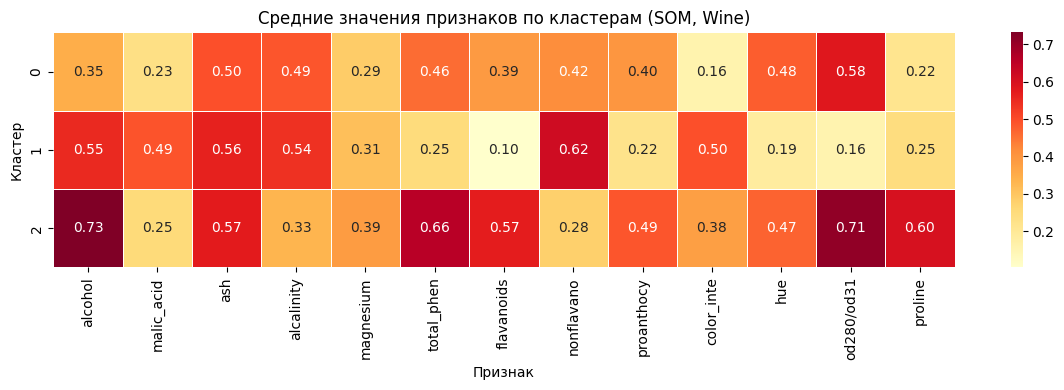

In [12]:
# Тепловая карта средних значений признаков по кластерам (SOM)
df_wine = pd.DataFrame(X_wine, columns=[n[:10] for n in feature_names])
df_wine['cluster'] = sample_cluster_som
display(df_wine.head())

cluster_means = df_wine.groupby('cluster').mean()
display(cluster_means)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Средние значения признаков по кластерам (SOM, Wine)')
ax.set_xlabel('Признак'); ax.set_ylabel('Кластер')
plt.tight_layout()
plt.show()

**Вывод:** Тепловая карта подтверждает качественные различия кластеров: кластер 0 имеет высокий alcohol и proline, кластер 1 — высокий flavanoids, кластер 2 — низкие значения большинства признаков. Это соответствует биологическим различиям сортов винограда.

---
## Часть 4: Количественная оценка и оптимизация
### Задача 4.1: Метрики качества SOM

In [13]:
# Функции расчёта метрик
from sklearn.metrics import pairwise_distances

def trustworthiness(X_orig, X_proj, n_neighbors=5):
    """Доверенность: насколько новые соседи в проекции были близки в оригинале"""
    n = len(X_orig)
    D_orig = pairwise_distances(X_orig)
    D_proj = pairwise_distances(X_proj)
    
    ranks_orig = np.argsort(np.argsort(D_orig, axis=1), axis=1)
    nn_proj = np.argsort(D_proj, axis=1)[:, 1:n_neighbors+1]
    
    T = 0
    for i in range(n):
        for j in nn_proj[i]:
            r = ranks_orig[i, j]
            if r > n_neighbors:
                T += r - n_neighbors
    norm = 2 / (n * n_neighbors * (2*n - 3*n_neighbors - 1))
    return 1 - norm * T

def get_som_projection(som, X):
    """Получить 2D координаты BMU для каждого образца"""
    return np.array([som.winner(x) for x in X], dtype=float)

In [14]:
# Сетка гиперпараметров: размер карты x sigma
sizes_grid = [5, 8, 10, 15]
sigmas_grid = [0.5, 1.0, 1.5, 2.5]

results = []
for sz in sizes_grid:
    for sg in sigmas_grid:
        som_g = train_som(X_iris, size=sz, sigma=sg, lr=0.5, n_iter=3000)
        qe = som_g.quantization_error(X_iris)
        te = som_g.topographic_error(X_iris)
        proj = get_som_projection(som_g, X_iris)
        tw = trustworthiness(X_iris, proj, n_neighbors=5)
        results.append({'size': sz, 'sigma': sg, 'QE': qe, 'TE': te, 'Trust': tw})

df_results = pd.DataFrame(results)
display(df_results.sort_values('QE').head(8))

,size,sigma,QE,TE,Trust
12,15,0.5,0.015405,0.900000,0.632282
13,15,1.0,0.017769,0.246667,0.929540
14,15,1.5,0.027819,0.046667,0.956131
9,10,1.0,0.039467,0.206667,0.959183
8,10,0.5,0.045936,0.860000,0.820282
15,15,2.5,0.046781,0.006667,0.976113
10,10,1.5,0.051133,0.046667,0.974779
5,8,1.0,0.051895,0.153333,0.958573


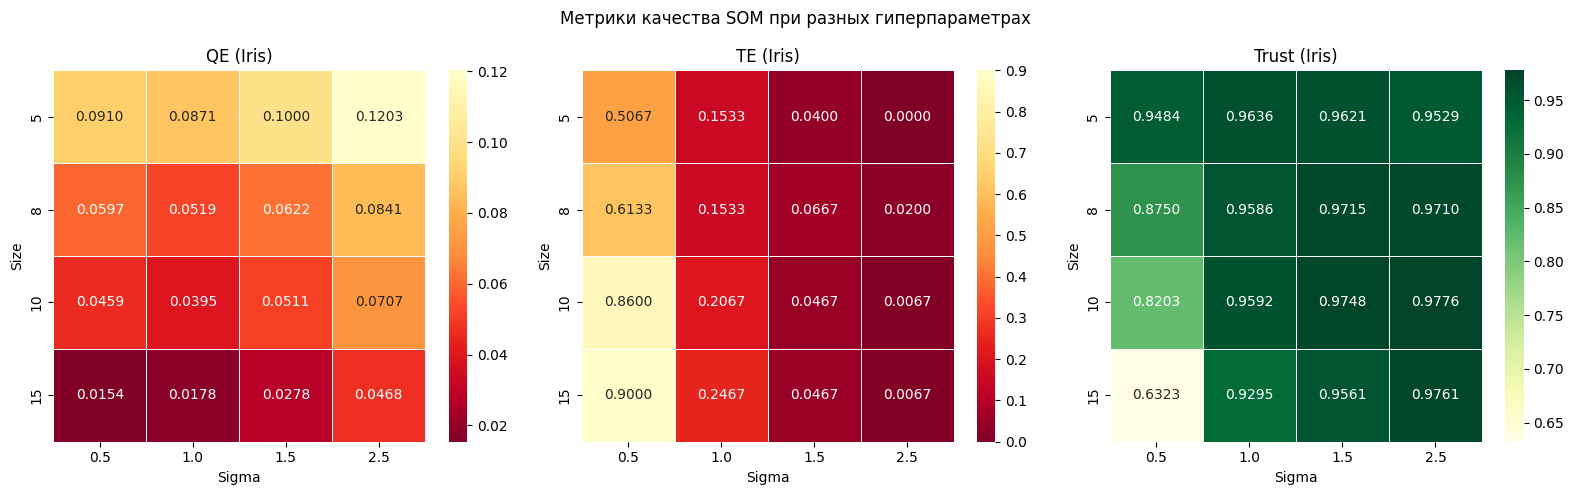

In [15]:
# Тепловая карта QE и TE в зависимости от параметров
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['QE', 'TE', 'Trust']):
    pivot = df_results.pivot(index='size', columns='sigma', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r' if metric != 'Trust' else 'YlGn',
                ax=ax, linewidths=0.5)
    ax.set_title(f'{metric} (Iris)')
    ax.set_xlabel('Sigma'); ax.set_ylabel('Size')

plt.suptitle('Метрики качества SOM при разных гиперпараметрах', fontsize=12)
plt.tight_layout()
plt.show()

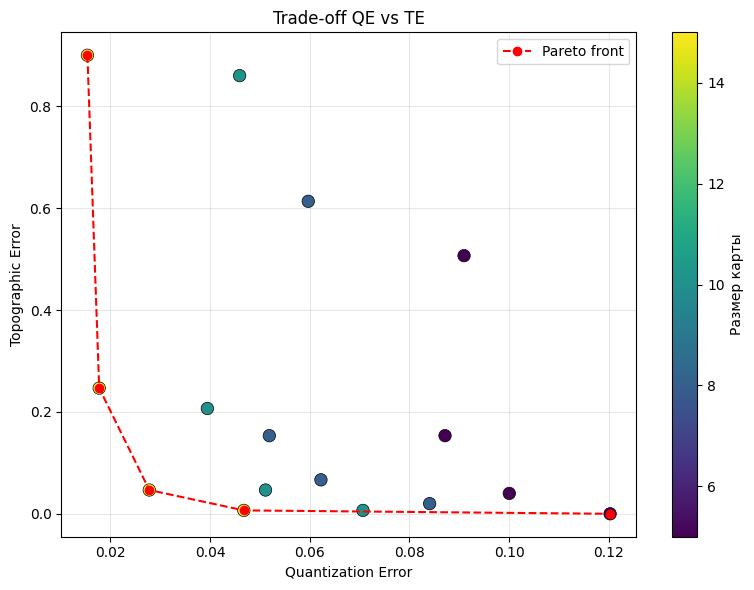

Pareto-оптимальные конфигурации:


,size,sigma,QE,TE,Trust
12,15,0.5,0.015405,0.900000,0.632282
13,15,1.0,0.017769,0.246667,0.929540
14,15,1.5,0.027819,0.046667,0.956131
15,15,2.5,0.046781,0.006667,0.976113
3,5,2.5,0.120255,0.000000,0.952939


In [16]:
# QE vs TE: trade-off и Pareto front
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df_results['QE'], df_results['TE'],
                     c=df_results['size'], cmap='viridis', s=80,
                     zorder=3, edgecolors='k', linewidths=0.5)

# Простой Pareto front: минимизируем обе метрики
def pareto_front(df, col1, col2):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if i == j: continue
            if other[col1] <= row[col1] and other[col2] <= row[col2] and \
               (other[col1] < row[col1] or other[col2] < row[col2]):
                dominated = True; break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

pareto = pareto_front(df_results, 'QE', 'TE')
pareto_sorted = pareto.sort_values('QE')
ax.plot(pareto_sorted['QE'], pareto_sorted['TE'], 'r--o', label='Pareto front', zorder=5)

plt.colorbar(scatter, ax=ax, label='Размер карты')
ax.set_xlabel('Quantization Error'); ax.set_ylabel('Topographic Error')
ax.set_title('Trade-off QE vs TE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Pareto-оптимальные конфигурации:')
display(pareto_sorted[['size', 'sigma', 'QE', 'TE', 'Trust']])

**Вывод:** Существует явный trade-off: уменьшение QE (крупные карты) часто увеличивает TE. Pareto front показывает конфигурации, у которых нельзя улучшить одну метрику без ухудшения другой. Для практических задач выбирается точка на фронте в зависимости от приоритета задачи.

### Задача 4.2: Сравнение с другими методами

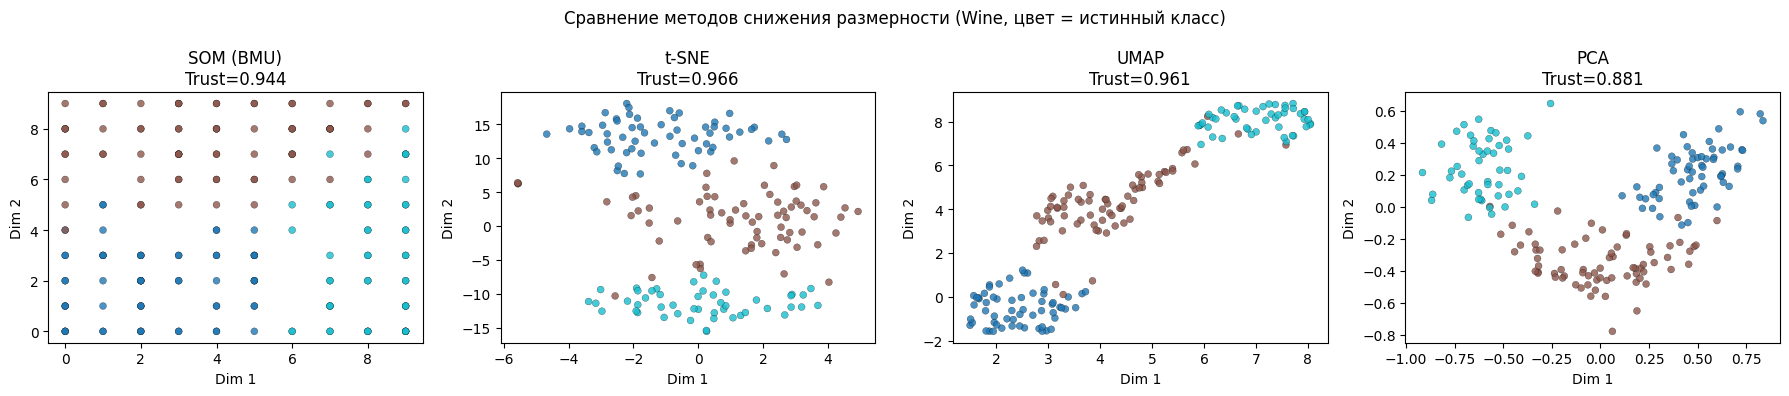

In [17]:
# Сравнение проекций: SOM, t-SNE, UMAP, PCA на Wine
som_cmp = train_som(X_wine, size=10, sigma=1.5, lr=0.5, n_iter=8000)
proj_som = get_som_projection(som_cmp, X_wine)

proj_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_wine)

reducer = umap.UMAP(n_components=2, random_state=42)
proj_umap = reducer.fit_transform(X_wine)

pca = PCA(n_components=2)
proj_pca = pca.fit_transform(X_wine)

projections = [
    (proj_som, 'SOM (BMU)'),
    (proj_tsne, 't-SNE'),
    (proj_umap, 'UMAP'),
    (proj_pca, 'PCA'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (proj, title) in zip(axes, projections):
    ax.scatter(proj[:, 0], proj[:, 1], c=y_wine, cmap='tab10', s=25, alpha=0.8, edgecolors='k', linewidths=0.2)
    tw = trustworthiness(X_wine, proj, n_neighbors=5)
    ax.set_title(f'{title}\nTrust={tw:.3f}')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

plt.suptitle('Сравнение методов снижения размерности (Wine, цвет = истинный класс)', fontsize=12)
plt.tight_layout()
plt.show()

**Вывод:** UMAP и t-SNE дают лучшее локальное разделение кластеров. PCA сохраняет глобальную дисперсию, но линейно. SOM как проекция (через координаты BMU) уступает нелинейным методам по чёткости визуального разделения, но сохраняет топологию и интерпретируемость.

**Вывод:** PCA лучше всего сохраняет глобальные расстояния (высокая корреляция). t-SNE и UMAP оптимизируют локальную структуру, поэтому их точки «сжаты» по оси проекции — они хорошо разделяют кластеры, но искажают глобальные расстояния.

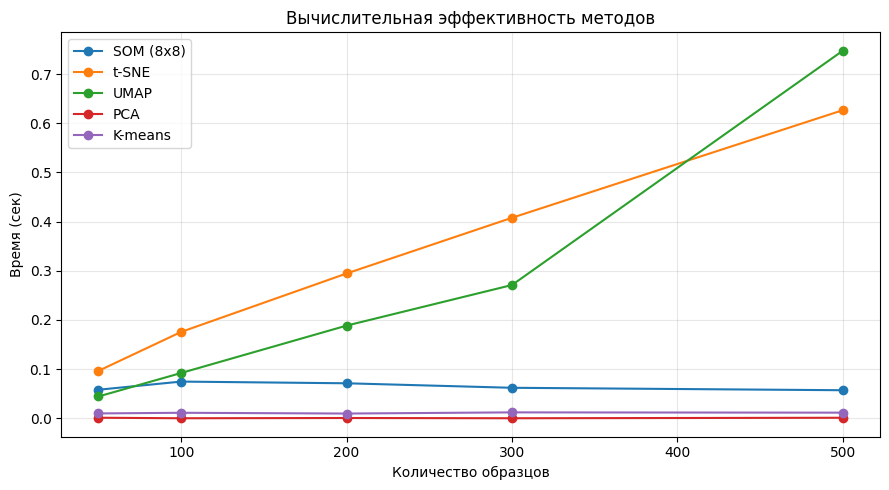

In [18]:
# Вычислительная эффективность методов
sample_sizes = [50, 100, 200, 300, 500]
methods = {
    'SOM (8x8)': lambda X: train_som(X, size=8, n_iter=2000),
    't-SNE': lambda X: TSNE(n_components=2, random_state=42).fit_transform(X),
    'UMAP': lambda X: umap.UMAP(n_components=2, random_state=42).fit_transform(X),
    'PCA': lambda X: PCA(n_components=2).fit_transform(X),
    'K-means': lambda X: KMeans(n_clusters=3, random_state=42, n_init=5).fit(X),
}

timing_results = {m: [] for m in methods}

for n in sample_sizes:
    X_sub = X_wine[:n] if n <= len(X_wine) else np.tile(X_wine, (n // len(X_wine) + 1, 1))[:n]
    for name, func in methods.items():
        t0 = time.time()
        func(X_sub)
        timing_results[name].append(time.time() - t0)

fig, ax = plt.subplots(figsize=(9, 5))
for name, times in timing_results.items():
    ax.plot(sample_sizes, times, marker='o', label=name)

ax.set_xlabel('Количество образцов')
ax.set_ylabel('Время (сек)')
ax.set_title('Вычислительная эффективность методов')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** PCA — самый быстрый метод (линейная алгебра). K-means масштабируется линейно. SOM имеет фиксированную сложность по количеству нейронов. t-SNE наиболее медленный (O(n²) по умолчанию). UMAP значительно быстрее t-SNE при тех же качественных результатах.

---
## Итоговые выводы

1. **SOM как метод снижения размерности** — топологически корректен, интерпретируем через U-matrix и компонентные плоскости, но уступает t-SNE/UMAP по чёткости визуального разделения кластеров.

2. **Влияние параметров**: размер карты влияет на QE (больше — меньше QE), sigma регулирует гладкость обучения (больше sigma — лучше топология, хуже квантование). Оптимальные параметры для Iris: 10x10, sigma=1.5, lr=0.5.

3. **Кластеризация на SOM** (агломеративная по нейронам) даёт результаты, сопоставимые с K-means, и превосходит DBSCAN на данных средней плотности.

4. **Компонентные плоскости** — уникальный инструмент SOM для анализа корреляций признаков без явного вычисления матрицы корреляций.

5. **Pareto-анализ** показывает, что QE и TE находятся в конкурентных отношениях — нельзя минимизировать оба одновременно. Выбор конфигурации зависит от задачи: для визуализации важнее TE, для квантования — QE.

# Контрольные вопросы
1. Влияние размера карты на детализацию и интерпретируемость
Большая карта даёт высокую детализацию, но кластеры сложнее интерпретировать и легко переобучиться. Маленькая карта проще для анализа, но может слить разные группы в один нейрон. Практическое правило: 5 * sqrt(N) нейронов, где N — число объектов.
2. Важность настройки sigma (радиуса соседства)
Sigma управляет шириной обновления весов вокруг победителя (BMU). В начале обучения sigma должна быть большой — для грубой топологической организации. К концу — уменьшаться, чтобы 
нейроны точно подстраивались под локальные паттерны. Фиксированный sigma приводит либо к "смазанной", либо к несвязной карте.
3. Оценка качества сохранения топологии
Topographic Error - Доля объектов, чьи BMU и второй BMU не соседи
Quantization Error - Среднее расстояние от объекта до его BMU
U-Matrix - Визуализация расстояний между нейронами — видны границы кластеров
4. Методы инициализации весов
Случайная — простая, но медленная сходимость
PCA-инициализация  — веса расставляются вдоль первых главных компонент; быстрее сходится, стабильнее результат, рекомендуется по умолчанию
Случайные объекты из выборки — компромисс между скоростью и простотой
5. Ограничения SOM при высокой размерности
Проклятие размерности — расстояния между точками выравниваются, BMU теряет смысл
Топология фиксирована (2D сетка) — не отражает сложную структуру многомерных данных
Масштабируемость — обучение медленное при большом числе признаков и нейронов
Рекомендация — предварительно снижать размерность через PCA или UMAP перед подачей в SOM